In [ ]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, to_date, year
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

spark = SparkSession.builder.appName("HealthcareAnalysis").getOrCreate()

file_path = "cleaned_healthcare_dataset.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

df.show()

+------------------+---+------+----------+-----------------+-----------------+-----------------+--------------------+------------------+------------------+-----------+--------------+--------------+-----------+------------+
|              Name|Age|Gender|Blood Type|Medical Condition|Date of Admission|           Doctor|            Hospital|Insurance Provider|    Billing Amount|Room Number|Admission Type|Discharge Date| Medication|Test Results|
+------------------+---+------+----------+-----------------+-----------------+-----------------+--------------------+------------------+------------------+-----------+--------------+--------------+-----------+------------+
|         Carl Best| 60|  male|        B+|     Hypertension|       2022-08-22|   Gregory Hansen|            Ltd Wang|        Blue Cross| 26062.43432029105|        482|      Elective|    2022-09-07|Paracetamol|Inconclusive|
|  Joseph Gutierrez| 82|  male|        A+|          Obesity|       2024-03-10|Christopher Mills|      Avery 

In [ ]:
df = df.withColumn("Date of Admission", to_date(col("Date of Admission")))
df = df.withColumn("Discharge Date", to_date(col("Discharge Date")))

In [ ]:
print(f"Total number of columns: {len(df.columns)}")
print(f"Total number of rows: {df.count()}")
print(f"Total number of duplicate rows: {df.count() - df.dropDuplicates().count()}")

Total number of columns: 15
Total number of rows: 54966
Total number of duplicate rows: 0


# **Matplotlib Visualizations**

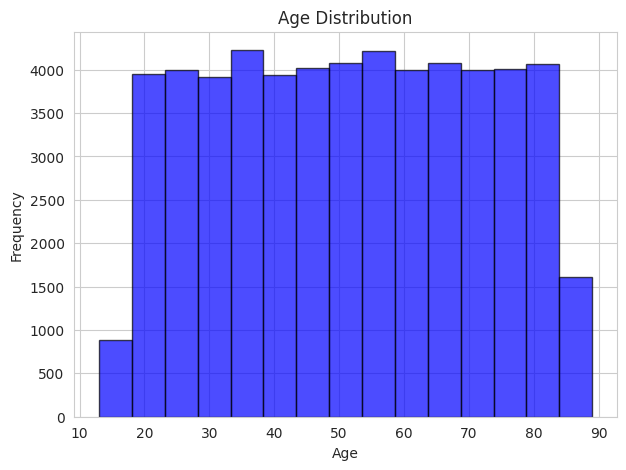

In [ ]:
#1
#Age Distribution
#Histogram tas KDE
age_data = df.select("Age").rdd.flatMap(lambda x: x).collect()
plt.figure(figsize=(7, 5))
plt.hist(age_data, bins=15, color='blue', edgecolor='black', alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()



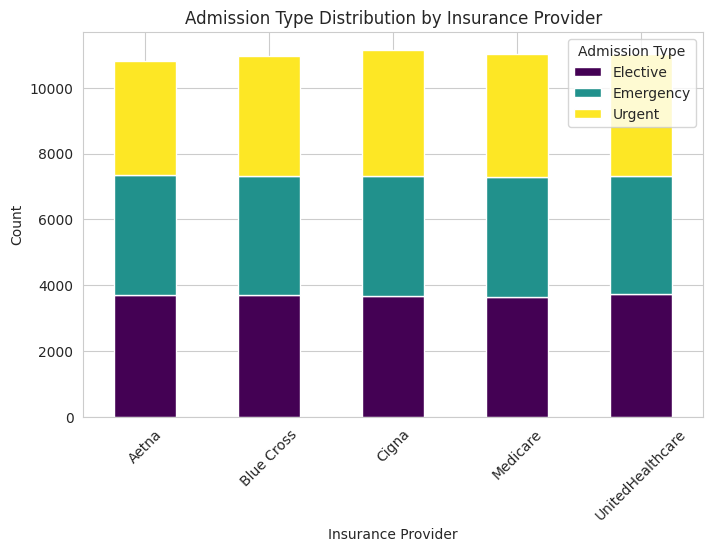

In [ ]:
#2
#Admission and Insurance Provider Dist
#Stacked Bar Chart
df_grouped = df.groupBy("Insurance Provider", "Admission Type").count().toPandas().pivot(index="Insurance Provider", columns="Admission Type", values="count").fillna(0)
df_grouped.plot(kind="bar", stacked=True, colormap='viridis', figsize=(8,5))
plt.xlabel("Insurance Provider")
plt.ylabel("Count")
plt.title("Admission Type Distribution by Insurance Provider")
plt.xticks(rotation=45)
plt.legend(title="Admission Type")
plt.show()

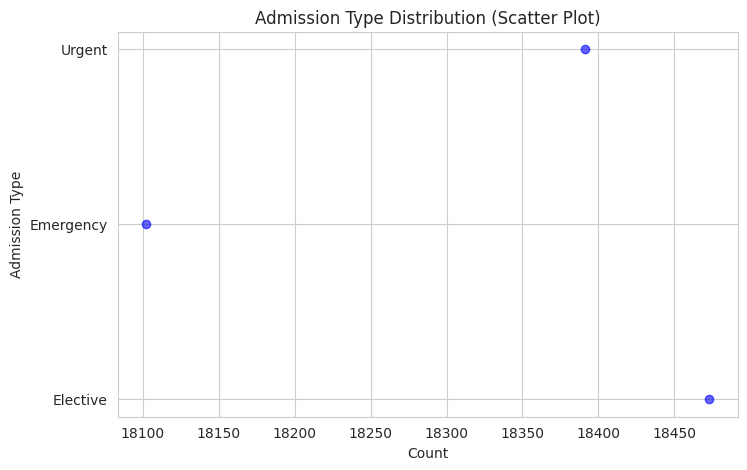

In [ ]:
#3
#Admission Type Distribution
admission_type_counts = df.groupBy("Admission Type").agg(count("Admission Type").alias("count")).toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(admission_type_counts["count"], admission_type_counts["Admission Type"], color='blue', alpha=0.6)

plt.title("Admission Type Distribution (Scatter Plot)")
plt.xlabel("Count")
plt.ylabel("Admission Type")
plt.show()

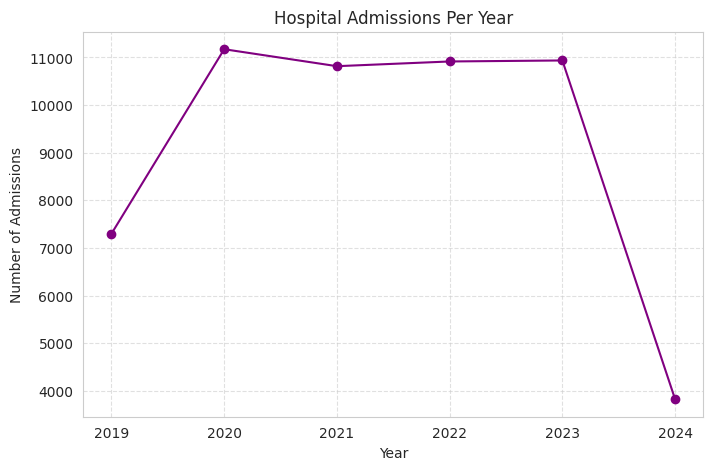

In [ ]:
#4
#Admissions per Year
#Line Plot
df_yearly = df.groupBy(year(col("Date of Admission")).alias("Year")).count().orderBy("Year").toPandas()
plt.figure(figsize=(8, 5))
plt.plot(df_yearly["Year"], df_yearly["count"], marker='o', linestyle='-', color='purple')
plt.xlabel("Year")
plt.ylabel("Number of Admissions")
plt.title("Hospital Admissions Per Year")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

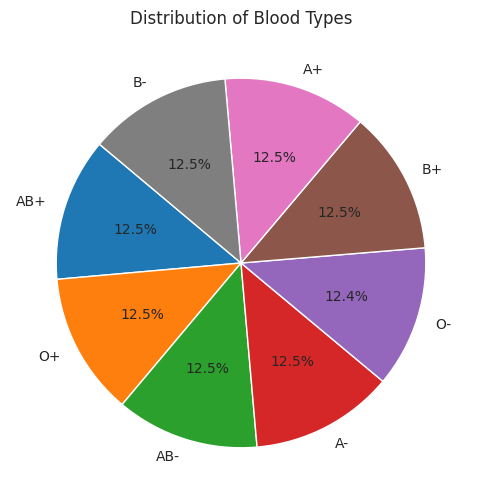

In [ ]:
#5
#Blood type distribution
#Pie chart
df_selected = df.select("Blood Type")
blood_type_counts = df_selected.groupBy("Blood Type").count().toPandas()
plt.figure(figsize=(8, 6))
plt.pie(blood_type_counts["count"], labels=blood_type_counts["Blood Type"], autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Blood Types")
plt.show()


# Seaborn Visualization

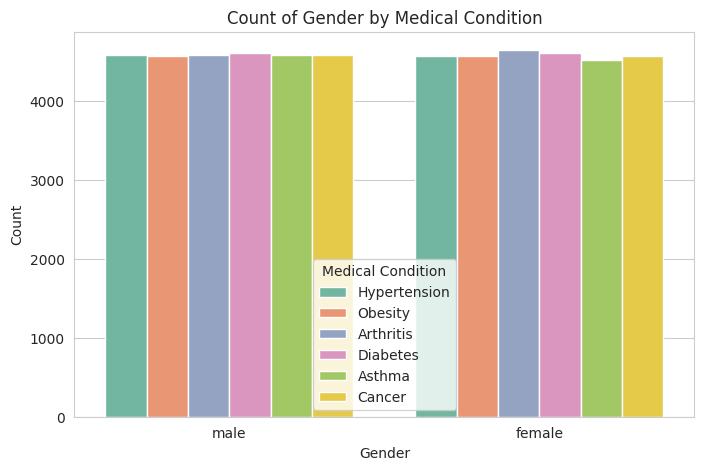

In [ ]:
# 1
# Count of Gender by Medical Condition
# Count Plot
if not isinstance(df, pd.DataFrame):
    df = df.toPandas()
df["Gender"] = df["Gender"].astype(str)
df["Medical Condition"] = df["Medical Condition"].astype(str)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Gender", hue="Medical Condition", palette="Set2")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Count of Gender by Medical Condition")

plt.show()


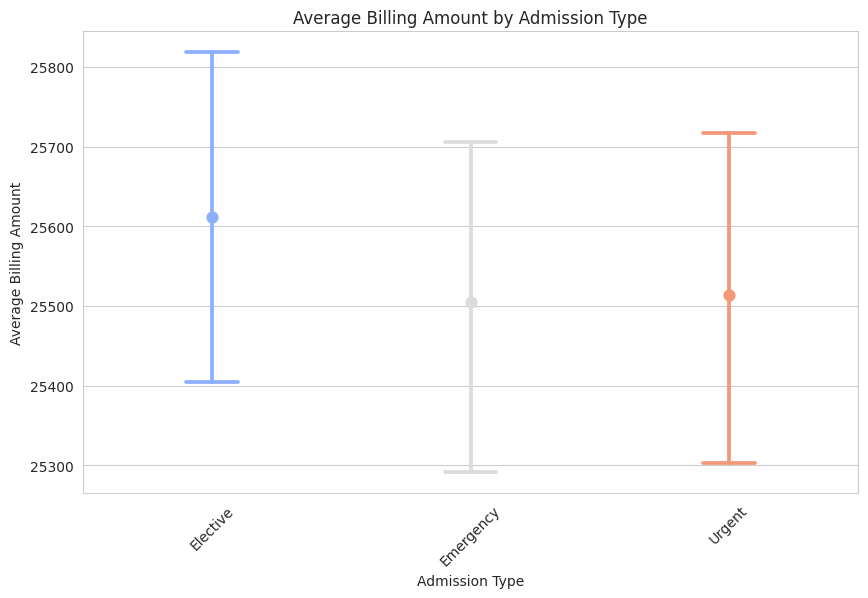

In [ ]:
# 2
# Average Billing Amount by Admission Type
# Point Plot
if not isinstance(df, pd.DataFrame):
    df = df.toPandas()
df["Billing Amount"] = pd.to_numeric(df["Billing Amount"], errors="coerce")
plt.figure(figsize=(10, 6))
sns.pointplot(x="Admission Type", y="Billing Amount", hue="Admission Type", data=df, capsize=0.2, palette="coolwarm", legend=False)
plt.xlabel("Admission Type")
plt.ylabel("Average Billing Amount")
plt.title("Average Billing Amount by Admission Type")
plt.xticks(rotation=45)
plt.show()


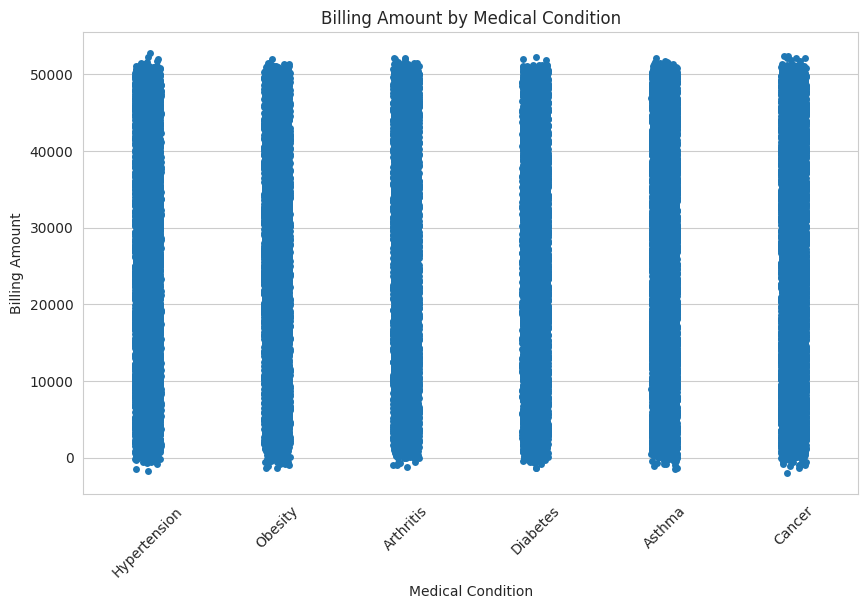

In [ ]:
# 3
# Billing Amount by Medical Condition
# Strip plot
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x="Medical Condition", y="Billing Amount", jitter=True)
plt.xticks(rotation=45)
plt.title("Billing Amount by Medical Condition")  # Added title
plt.show()


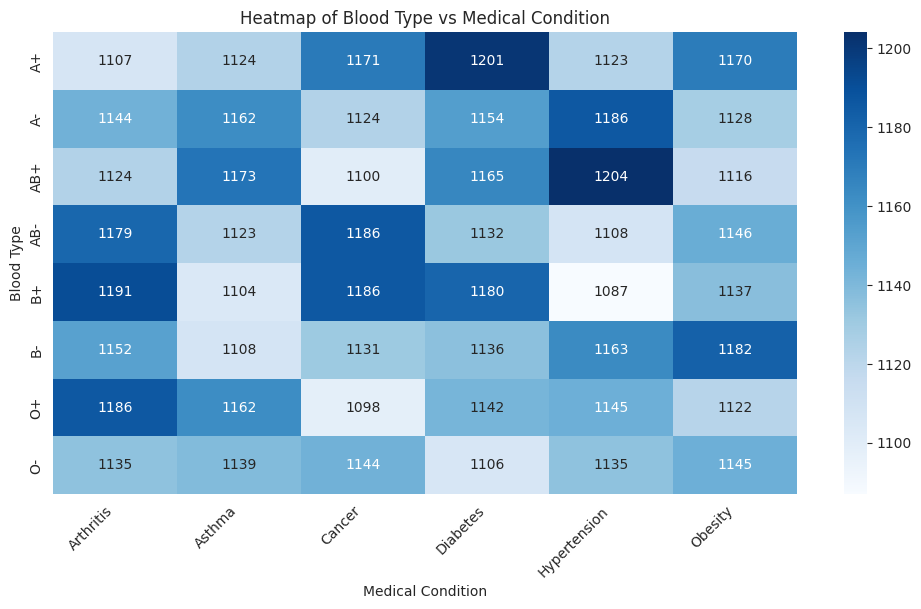

In [ ]:
# 4
# Heatmap of Blood Type vs Medical Condition
# Heatmap
df_cleaned = df[["Blood Type", "Medical Condition"]].dropna()
df_cleaned["Blood Type"] = df_cleaned["Blood Type"].astype(str).str.strip()
df_cleaned["Medical Condition"] = df_cleaned["Medical Condition"].astype(str).str.strip()

heatmap_data = df_cleaned.pivot_table(index="Blood Type", columns="Medical Condition", aggfunc="size", fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d")
plt.title("Heatmap of Blood Type vs Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Blood Type")
plt.xticks(rotation=45, ha="right")
plt.show()


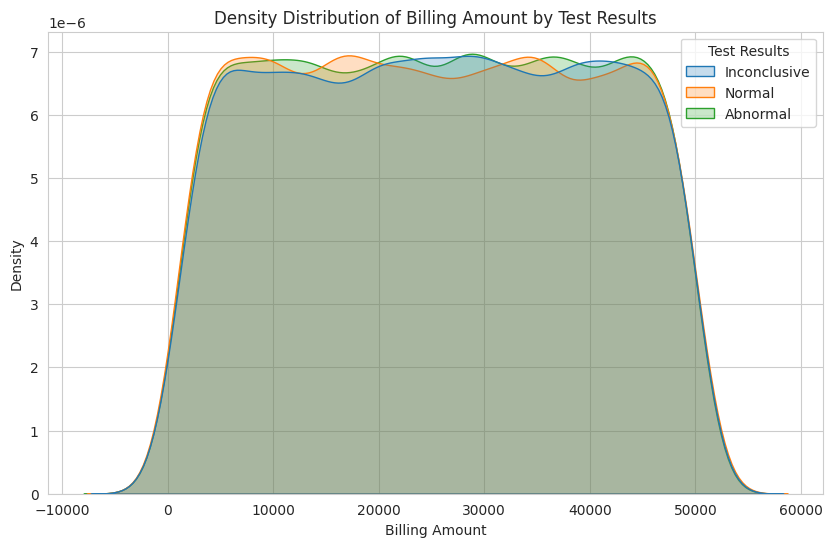

In [ ]:
# 5
# Density Distribution of Billing Amount by Test Results
# KDE Plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Billing Amount", hue="Test Results", fill=True)
plt.title("Density Distribution of Billing Amount by Test Results")
plt.show()
